In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Recuperando os dados (caso esteja em um novo notebook)
# Se estiver no mesmo notebook, pode ignorar esta célula
extract_path = "../data/raw/"
df = pd.read_csv(extract_path + "SMSSpamCollection", sep='\t', names=["label", "mensagem"])

# 2. Codificação da Variável Alvo
# Transformando 'ham' (normal) e 'spam' em 0 e 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# 3. Separação de Treino e Teste
X = df['mensagem']
y = df['label_num']

# Usamos stratify=y para garantir que a proporção de spam/ham seja a mesma no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Mensagens para treino: {X_train.shape[0]}")
print(f"Mensagens para teste: {X_test.shape[0]}")

# 4. Engenharia de Features (Vetorização)
# O TF-IDF vai converter o texto em uma matriz numérica, dando menos peso para palavras muito comuns
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)

# Atenção: usamos fit_transform no treino e APENAS transform no teste para evitar vazamento de dados (Data Leakage)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nPré-processamento concluído com sucesso! 🚀")
print(f"Formato da matriz de treino: {X_train_tfidf.shape} (linhas, palavras únicas)")
print(f"Formato da matriz de teste: {X_test_tfidf.shape}")

Mensagens para treino: 4457
Mensagens para teste: 1115

Pré-processamento concluído com sucesso! 🚀
Formato da matriz de treino: (4457, 7403) (linhas, palavras únicas)
Formato da matriz de teste: (1115, 7403)


=== Resultados do Modelo: Regressão Logística ===
Acurácia:  0.9677 (Taxa de acertos gerais)
Precisão:  1.0000 (Quando diz que é spam, quão correto está?)
Recall:    0.7584 (Dos spams reais, quantos ele encontrou?)
F1-Score:  0.8626 (Média harmônica entre Precisão e Recall)


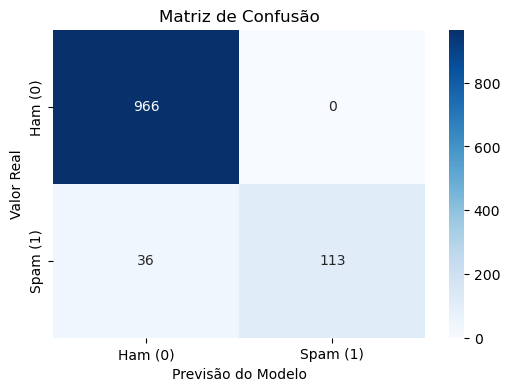

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Instanciando e Treinando o Modelo
# max_iter=1000 garante que o algoritmo tenha tempo de convergir
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_tfidf, y_train)

# 2. Fazendo Previsões no conjunto de teste
y_pred = modelo_lr.predict(X_test_tfidf)

# 3. Calculando as Métricas Exigidas
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Resultados do Modelo: Regressão Logística ===")
print(f"Acurácia:  {acuracia:.4f} (Taxa de acertos gerais)")
print(f"Precisão:  {precisao:.4f} (Quando diz que é spam, quão correto está?)")
print(f"Recall:    {recall:.4f} (Dos spams reais, quantos ele encontrou?)")
print(f"F1-Score:  {f1:.4f} (Média harmônica entre Precisão e Recall)")

# 4. Visualização: Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Previsão do Modelo')
plt.show()